# Sésame, ouvre-toi — Partie 2 : Feature Engineering & Modélisation

Ce notebook fait suite à `sesame_partie1_eda.ipynb` (récupération des 3 tables + analyse exploratoire comparative). Conformément au cahier des charges, il regroupe l'ensemble du **pipeline de modélisation** : feature engineering, entraînement, optimisation d'hyperparamètres, explicabilité (SHAP) et audit d'équité — construit **section par section**.

---
## Sommaire de ce notebook
- **2.1 Feature Engineering** *(cette section)*
- 2.2 Choix et entraînement du/des modèle(s)
- 2.3 Optimisation des hyperparamètres (Optuna)
- 2.4 Évaluation & métriques
- 2.5 Explicabilité (SHAP / LIME / SAGE)
- 2.6 Audit d'équité & stratégies de mitigation

---
# 2.1 Feature Engineering

**Objectif de cette section :** transformer la table brute *"cox-violent-parsed"* (granularité dossier/charge, avec colonnes administratives et données manquantes structurelles) en un **jeu de données d'apprentissage propre**, avec une cible binaire claire, des features justifiées une à une, et un split train/test qui préserve la représentativité des groupes sensibles — condition nécessaire pour que l'audit d'équité mené plus loin soit valide statistiquement.


In [1]:
# --- Imports ---
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

RANDOM_STATE = 42


## 2.1.1 Reconstruction du cohort "récidive à 2 ans"

La table `cox-violent-parsed` contient **une ligne par dossier judiciaire**, avec des cas où l'issue (récidive) n'est pas connue, des charges sans lien réel avec l'évaluation COMPAS (dossiers trop anciens/récents par rapport au screening) et des lignes dupliquées sans identifiant valide.

On applique ici la méthodologie de nettoyage documentée par ProPublica (*How We Analyzed the COMPAS Recidivism Algorithm*), en la justifiant étape par étape plutôt qu'en l'appliquant aveuglément :

| Filtre | Justification |
|---|---|
| `id` non manquant | Les lignes à `id` manquant proviennent d'une portion du pipeline source ProPublica qui n'attache pas d'identifiant fiable (vérifié empiriquement : parmi les personnes ayant au moins une ligne sans `id`, **98 % n'ont aucune autre ligne avec un `id` valide dans le fichier** — ce ne sont donc pas, pour l'essentiel, des doublons d'une personne déjà comptée ailleurs, mais des enregistrements qu'on ne peut pas rattacher de façon fiable à un individu identifiable). Sans `id` fiable, on ne peut pas garantir l'unicité de l'observation ni la relier proprement aux autres tables (audit, comparaison avec le score COMPAS) — on les retire donc par prudence méthodologique plutôt que pour éviter une duplication de personne. |
| `c_charge_degree` non manquant | Les charges sans degré (F/M) correspondent essentiellement à des infractions de type "ordonnance locale" (stationnement, trafic...) hors du périmètre pénal que COMPAS est censé évaluer. Les inclure ajouterait du **bruit non pertinent** à la tâche. |
| `days_b_screening_arrest` ∈ [-30, 30] | Ce délai mesure l'écart entre la date d'arrestation liée à la charge et la date de screening COMPAS. Un écart trop important signifie que le **score évalué n'est probablement pas celui de cette charge précise** (erreur d'appariement dans les données sources) — les conserver introduirait du bruit dans la relation feature → score. |
| `is_recid != -1` | La valeur -1 signifie que l'issue de récidive n'est **pas connue** (dossier trop récent pour observer 2 ans de suivi). Sans label fiable, ces lignes ne peuvent pas servir à l'apprentissage supervisé. |

Chaque filtre retire des lignes **pour une raison métier explicite**, ce qui diffère d'une suppression arbitraire de valeurs manquantes.


In [2]:
cox = pd.read_csv("data/cox-violent-parsed.csv")
print(f"Table source (cox-violent-parsed) : {cox.shape[0]:,} lignes")

df = cox.copy()

etapes = []

df = df[df["id"].notna()]
etapes.append(("id non manquant", len(df)))

df = df[df["c_charge_degree"].notna()]
etapes.append(("c_charge_degree renseigné", len(df)))

df = df[(df["days_b_screening_arrest"] >= -30) & (df["days_b_screening_arrest"] <= 30)]
etapes.append(("days_b_screening_arrest dans [-30, 30]", len(df)))

df = df[df["is_recid"] != -1]
etapes.append(("is_recid connu (0 ou 1)", len(df)))

suivi = pd.DataFrame(etapes, columns=["Filtre appliqué", "Lignes restantes"])
suivi["Lignes retirées"] = suivi["Lignes restantes"].diff().fillna(cox.shape[0] - suivi["Lignes restantes"].iloc[0]).abs().astype(int)
display(suivi)

print(f"\nCohort final : {df.shape[0]:,} prévenus (contre {cox['id'].nunique():,.0f} avant filtrage qualité)")


Table source (cox-violent-parsed) : 18,316 lignes


,Filtre appliqué,Lignes restantes,Lignes retirées
0,id non manquant,11001,7315
1,c_charge_degree renseigné,10511,490
2,"days_b_screening_arrest dans [-30, 30]",8899,1612
3,is_recid connu (0 ou 1),8899,0



Cohort final : 8,899 prévenus (contre 11,001 avant filtrage qualité)


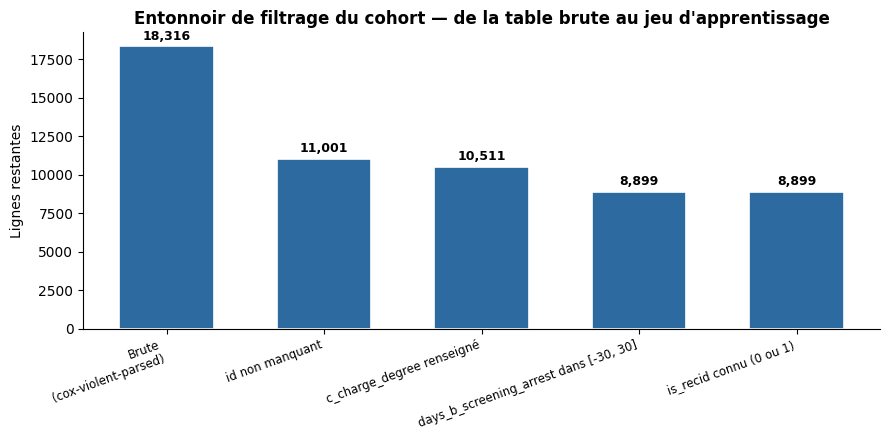

In [3]:
import matplotlib.pyplot as plt

etapes_labels = ["Brute\n(cox-violent-parsed)"] + [nom for nom, _ in etapes]
etapes_valeurs = [cox.shape[0]] + [n for _, n in etapes]

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(range(len(etapes_valeurs)), etapes_valeurs, color='#2D6A9F', edgecolor='white',
              linewidth=1.2, width=0.6)
for i, v in enumerate(etapes_valeurs):
    ax.text(i, v + 250, f'{v:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(range(len(etapes_labels)))
ax.set_xticklabels(etapes_labels, rotation=20, ha='right', fontsize=8.5)
ax.set_ylabel("Lignes restantes")
ax.set_title("Entonnoir de filtrage du cohort — de la table brute au jeu d'apprentissage",
             fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [4]:
# Vérification : la structure démographique du cohort final reste-t-elle comparable à la table brute ?
comparaison = pd.DataFrame({
    "Table brute (id unique)": cox.drop_duplicates("id")["race"].value_counts(normalize=True).round(3),
    "Cohort final filtré": df["race"].value_counts(normalize=True).round(3),
}).fillna(0)
comparaison


,Table brute (id unique),Cohort final filtré
race,,
African-American,0.533,0.536
Caucasian,0.335,0.334
Hispanic,0.076,0.071
Other,0.048,0.053
Asian,0.004,0.004
Native American,0.003,0.002


**Lecture :** les proportions par groupe ethnique restent quasiment inchangées après filtrage (écarts < 1 point). Le nettoyage ne **déséquilibre pas artificiellement** la représentativité des groupes — condition importante puisque ce sont ces groupes qui seront comparés lors de l'audit d'équité.


## 2.1.2 Définition de la cible

La table dispose des colonnes `start`, `end`, `event`, qui permettent en théorie une **analyse de survie** (modèle de Cox — d'où le nom du fichier) : le risque de récidive pourrait être modélisé comme le temps écoulé avant l'événement plutôt que comme un simple binaire.

**Choix retenu : classification binaire sur `is_recid`** (a récidivé dans la fenêtre de suivi = 1/0), et non une analyse de survie complète.

*Justification (biais/variance/complexité) :*
- Le brief demande explicitement un **modèle de prédiction** comparable aux scores COMPAS eux-mêmes construits comme des scores de classification (`decile_score`, `score_text`) — une classification binaire est directement comparable et permet de réutiliser les métriques et l'appareillage d'explicabilité (SHAP) les plus matures pour ce type de sortie.
- Un modèle de survie ajoute un degré de complexité (fonction de risque, censure) sans bénéfice direct pour répondre à la question d'équité posée par le brief, qui compare des **groupes à un instant donné** (parité démographique, égalité des chances) — ce sont des métriques définies pour la classification.
- On documente ce choix comme **piste d'extension possible** plutôt que comme un impensé.


In [5]:
df["two_year_recid"] = df["is_recid"].astype(int)

print("Distribution de la cible :")
display(df["two_year_recid"].value_counts(normalize=True).rename("proportion").round(3))
print(f"\nRatio de déséquilibre : {df['two_year_recid'].value_counts().max() / df['two_year_recid'].value_counts().min():.2f}")


Distribution de la cible :


two_year_recid
0    0.514
1    0.486
Name: proportion, dtype: float64


Ratio de déséquilibre : 1.06


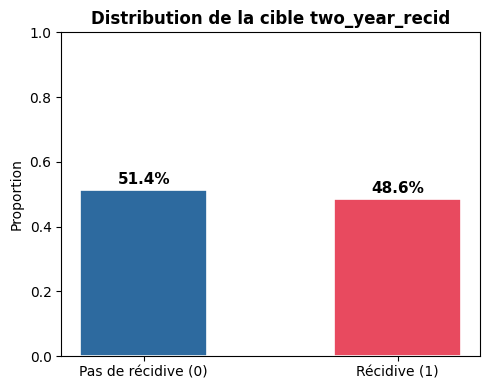

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df["two_year_recid"].value_counts().sort_index()
labels_target = ["Pas de récidive (0)", "Récidive (1)"]
colors_target = ['#2D6A9F', '#E84A5F']
bars = ax.bar(labels_target, counts.values / counts.sum(), color=colors_target,
              edgecolor='white', linewidth=1.2, width=0.5)
for p, v in zip(bars, counts.values / counts.sum()):
    ax.text(p.get_x()+p.get_width()/2, v+0.01, f'{v:.1%}', ha='center', va='bottom',
            fontsize=11, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_ylabel("Proportion")
ax.set_title("Distribution de la cible two_year_recid", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Lecture :** la cible est quasiment équilibrée (~51 %/49 %). Un déséquilibre aussi faible **ne justifie pas** de sur/sous-échantillonnage (SMOTE, class_weight agressif) au stade du modèle principal — cela reviendrait à ajouter de la variance artificielle sans bénéfice, la métrique d'accuracy ne serait déjà pas trompeuse ici. On gardera toutefois `class_weight="balanced"` en option testable lors de l'optimisation d'hyperparamètres (section 2.3), et le rappel/precision par classe comme métriques principales plutôt que la seule accuracy (section 2.4).


## 2.1.3 Sélection, transformation et encodage des features

### Variable à traiter avec précaution : le score COMPAS lui-même

`decile_score` et `score_text` sont **exclus du vecteur d'entrée `X`** du modèle principal.

*Justification :* l'objectif du projet est d'auditer COMPAS, pas de le reproduire. Inclure le score COMPAS comme feature créerait une **fuite de cible circulaire** : COMPAS a été calibré pour prédire `is_recid`, donc l'utiliser comme predictor donnerait un modèle qui ne fait qu'imiter (et donc hériter mécaniquement) le biais qu'on cherche à mesurer, rendant l'audit tautologique. On conserve ces colonnes **à part** (non utilisées pour l'entraînement) afin de comparer, en section 2.4, les performances et l'équité de *notre* modèle indépendant vs. celles du score COMPAS existant.

### Autres features retenues


In [7]:
# --- Age : on garde la variable numérique brute plutôt que la version discrétisée `age_cat` ---
# Justification : la discrétisation en 3 classes ("< 25", "25-45", "> 45") fait perdre de l'information
# ordinale sans bénéfice de robustesse ici (peu de valeurs aberrantes sur l'âge) -> variance inutile.
df["age"] = df["age"].astype(int)

# --- Sexe : encodage binaire simple (2 catégories, pas d'ordre) ---
df["is_male"] = (df["sex"] == "Male").astype(int)

# --- Antécédents judiciaires ---
# Justification : priors_count reste séparé (variable continue à forte valeur prédictive, cf. partie 1).
# Les 3 compteurs de délits juvéniles (juv_fel_count / juv_misd_count / juv_other_count) sont
# à >90% égaux à 0 individuellement (forte parcimonie) -> on les agrège en un compteur total
# `juv_total` pour réduire la dimensionnalité et la variance d'estimation sur des variables trop
# rares prises séparément, tout en conservant le signal "a un passé judiciaire de mineur".
df["juv_total"] = df["juv_fel_count"] + df["juv_misd_count"] + df["juv_other_count"]

# --- Gravité de la charge ---
# Justification : c_charge_degree contient 14 modalités très déséquilibrées sur la table complète
# de la partie 1 (12 restantes ici, après nos filtres de cohort, mais toujours très déséquilibrées).
# On le simplifie en un binaire Félonie/Délit (is_felony), qui capture la distinction pénale
# la plus significative sans exploser la dimensionnalité avec du one-hot sur 14 catégories
# rares (risque de surapprentissage sur des modalités à très faible effectif).
df["is_felony"] = df["c_charge_degree"].str.contains("F", na=False).astype(int)

features_num_bin = ["age", "is_male", "priors_count", "juv_total", "is_felony"]
df[features_num_bin].describe().T


,count,mean,std,min,25%,50%,75%,max
age,8899.0,33.865378,11.535246,18.0,25.0,31.0,41.0,96.0
is_male,8899.0,0.821441,0.383004,0.0,1.0,1.0,1.0,1.0
priors_count,8899.0,3.870997,5.229976,0.0,0.0,2.0,5.0,37.0
juv_total,8899.0,0.299921,1.036451,0.0,0.0,0.0,0.0,21.0
is_felony,8899.0,0.698505,0.458933,0.0,0.0,1.0,1.0,1.0


### Variable sensible : `race`

`race` n'est **pas incluse** dans le jeu de features principal `X` (approche dite *"fairness through unawareness"*), afin de tester une question centrale de l'audit : **retirer l'attribut sensible suffit-il à supprimer le biais ?**

On construit donc **deux jeux de features en parallèle** :
- `X` (sans `race`) → modèle principal, audité *a posteriori* par groupe.
- `X_avec_race` (avec `race` one-hot encodée) → modèle de comparaison, pour objectiver si la performance/l'équité change significativement lorsque l'attribut est explicitement disponible.

*Hypothèse à vérifier plus loin (section 2.6) :* la littérature (et l'analyse de la partie 1, où `priors_count` était déjà corrélé à `race`) suggère que retirer `race` ne suffit généralement pas, car d'autres variables (`priors_count` notamment) agissent comme **proxy** de l'attribut sensible.

**Asymétrie à noter :** contrairement à `race`, le **sexe** (`is_male`) n'est *pas* soumis au même traitement — il reste dans `X` comme feature directe (section 2.1.4), sans variante *unawareness* équivalente. Cette asymétrie n'a pas de justification métier explicite ici ; elle est testée empiriquement en section 2.6ter, à la lumière du déséquilibre par sexe découvert en 2.6bis.


In [8]:
# On conserve la race non pas comme feature exploitée pour la prédiction (sauf variante de comparaison),
# mais comme attribut d'audit "à part" (nécessaire pour calculer les métriques de fairness en 2.6).
races_principales = ["African-American", "Caucasian"]
# Justification : les groupes Hispanic/Other/Asian/Native American représentent chacun <10% de
# l'échantillon (cf. partie 1) -> les métriques de fairness calculées dessus auraient une variance
# d'estimation trop grande pour être interprétées de façon fiable. On les conserve dans le dataset
# complet, mais les comparaisons d'équité se concentreront sur les 2 groupes majoritaires.
df["race_agg"] = np.where(df["race"].isin(races_principales), df["race"], "Other/Minorité")

print(df["race_agg"].value_counts())


race_agg
African-American    4767
Caucasian           2974
Other/Minorité      1158
Name: count, dtype: int64


In [9]:
race_dummies = pd.get_dummies(df["race_agg"], prefix="race", drop_first=True)  # drop_first : évite la colinéarité parfaite (piège de la variable dummy)
race_dummies.head()


,race_Caucasian,race_Other/Minorité
0,False,True
1,False,True
3,False,False
4,False,False
5,False,False


## 2.1.4 Construction des jeux de features finaux

Récapitulatif des colonnes retenues :

| Variable | Type | Traitement | Dans `X` principal ? |
|---|---|---|---|
| `age` | numérique | brute | ✅ |
| `is_male` | binaire | encodage 0/1 | ✅ |
| `priors_count` | numérique | brute | ✅ |
| `juv_total` | numérique | somme des 3 compteurs juvéniles | ✅ |
| `is_felony` | binaire | simplification de `c_charge_degree` | ✅ |
| `race` | catégorielle | one-hot (agrégée) | ❌ (uniquement dans `X_avec_race`) |
| `decile_score` / `score_text` | — | conservées à part | ❌ (fuite de cible) |
| `two_year_recid` | binaire | — | Cible `y` |


In [10]:
FEATURES_BASE = ["age", "is_male", "priors_count", "juv_total", "is_felony"]

X = df[FEATURES_BASE].copy()
X_avec_race = pd.concat([X, race_dummies], axis=1)
y = df["two_year_recid"].copy()

# Attributs conservés à part pour l'audit d'équité et la comparaison avec COMPAS (non utilisés pour l'apprentissage)
audit_attrs = df[["race", "race_agg", "decile_score", "score_text", "sex"]].copy()

print("X (sans race)       :", X.shape)
print("X_avec_race         :", X_avec_race.shape)
print("y (cible)            :", y.shape)
X.head()


X (sans race)       : (8899, 5)
X_avec_race         : (8899, 7)
y (cible)            : (8899,)


,age,is_male,priors_count,juv_total,is_felony
0,69,1,0,0,1
1,69,1,0,0,1
3,34,1,0,0,1
4,24,1,4,1,1
5,24,1,4,1,1


## 2.1.5 Split train/test stratifié

**Choix : stratification conjointe sur la cible `y` ET sur le groupe `race_agg`.**

*Justification :* une stratification sur `y` seule garantirait un ratio de classes identique entre train et test, mais **pas** une représentativité comparable des groupes ethniques dans le jeu de test. Or l'audit d'équité de la section 2.6 sera calculé **sur le test set** : si un groupe minoritaire s'y retrouve sous-représenté par hasard, les métriques de fairness (calculées par sous-groupe) auraient une variance d'estimation excessive, potentiellement trompeuse. Stratifier sur les deux variables conjointement limite ce risque.


In [11]:
strate = df["two_year_recid"].astype(str) + "_" + df["race_agg"]

X_train, X_test, y_train, y_test, audit_train, audit_test = train_test_split(
    X, y, audit_attrs,
    test_size=0.2,
    stratify=strate,
    random_state=RANDOM_STATE,
)

# On aligne le split "avec race" sur les mêmes index (mêmes individus dans train/test que ci-dessus)
X_avec_race_train = X_avec_race.loc[X_train.index]
X_avec_race_test = X_avec_race.loc[X_test.index]

print(f"Train : {X_train.shape[0]:,} individus  |  Test : {X_test.shape[0]:,} individus")
print("\nVérification de la stratification (proportion de la cible) :")
print(pd.DataFrame({"train": y_train.value_counts(normalize=True), "test": y_test.value_counts(normalize=True)}).round(3))

print("\nVérification de la représentativité des groupes ethniques :")
print(pd.DataFrame({
    "train": audit_train["race_agg"].value_counts(normalize=True),
    "test": audit_test["race_agg"].value_counts(normalize=True),
}).round(3))


Train : 7,119 individus  |  Test : 1,780 individus

Vérification de la stratification (proportion de la cible) :
                train   test
two_year_recid              
0               0.514  0.514
1               0.486  0.486

Vérification de la représentativité des groupes ethniques :
                  train   test
race_agg                      
African-American  0.536  0.535
Caucasian         0.334  0.335
Other/Minorité    0.130  0.130


**Lecture :** les proportions de la cible et des groupes ethniques sont quasi identiques entre train et test (écarts < 1 point) — le split est donc représentatif sur les deux dimensions qui comptent pour la suite du projet (performance ET équité).


## 2.1.6 Sauvegarde des jeux de données

On sauvegarde des fichiers CSV intermédiaires afin que la section suivante (2.2 — choix et entraînement du modèle) puisse reprendre directement ces jeux de données propres, sans dépendre de l'exécution préalable de cette section dans la même session.


In [12]:
import os
os.makedirs("data/processed", exist_ok=True)

X_train.assign(split="train").to_csv("data/processed/X_train.csv", index=True)
X_test.assign(split="test").to_csv("data/processed/X_test.csv", index=True)
X_avec_race_train.to_csv("data/processed/X_avec_race_train.csv", index=True)
X_avec_race_test.to_csv("data/processed/X_avec_race_test.csv", index=True)
y_train.to_csv("data/processed/y_train.csv", index=True)
y_test.to_csv("data/processed/y_test.csv", index=True)
audit_train.to_csv("data/processed/audit_train.csv", index=True)
audit_test.to_csv("data/processed/audit_test.csv", index=True)

print("Fichiers sauvegardés dans data/processed/ :")
for f in sorted(os.listdir("data/processed")):
    print(" -", f)


Fichiers sauvegardés dans data/processed/ :
 - X_avec_race_test.csv
 - X_avec_race_train.csv
 - X_test.csv
 - X_train.csv
 - audit_test.csv
 - audit_train.csv
 - y_test.csv
 - y_train.csv


## 2.1.7 Synthèse de la section Feature Engineering

**Décisions prises et justifications :**

1. **Cohort reconstruit** (11 001 → 8 899 individus) via un filtrage qualité justifié métier (appariement score/charge, issue connue), sans déséquilibrer la répartition par groupe ethnique.
2. **Cible** : classification binaire `two_year_recid` — choix pragmatique par rapport à une analyse de survie, documenté comme piste d'extension.
3. **Features** réduites et justifiées une à une (agrégation des compteurs juvéniles rares, simplification de la gravité de charge, exclusion du score COMPAS pour éviter la fuite de cible).
4. **`race` volontairement exclue** du jeu de features principal (fairness through unawareness), avec un jeu alternatif `X_avec_race` préparé pour tester si cette exclusion suffit réellement à limiter le biais — question qui sera tranchée quantitativement en section 2.6.
5. **Split stratifié** sur cible + groupe ethnique pour garantir la validité statistique de l'audit d'équité mené sur le test set.

➡️ **Prochaine étape (2.2) :** choix justifié d'un ou plusieurs modèles de Machine Learning adaptés à la tâche, entraînement baseline, puis optimisation des hyperparamètres (Optuna).


## 2.2 Choix et entraînement du modèle

### Cadre de décision

Plutôt que de choisir un modèle par habitude, on structure le choix autour de 4 critères explicites, adaptés au contexte du projet :

| Critère | Contrainte du projet |
|---|---|
| Nature des données | Tabulaire, mélange numérique/binaire, peu de features (5), relations potentiellement non linéaires (ex. `priors_count`) |
| Taille d'échantillon | ~7 100 individus en train — ni trop petit (régularisation forte inutile), ni assez grand pour justifier un deep learning |
| Compatibilité explicabilité | Le brief impose SHAP (section 2.5) — le calcul de Shapley est **exact et rapide (TreeSHAP)** pour les modèles à base d'arbres, contre une approximation coûteuse (KernelSHAP) pour un modèle générique |
| Comparabilité à COMPAS | COMPAS produit un score de risque continu — on veut un modèle qui produise nativement des **probabilités calibrables**, pas seulement des classes |

On compare 3 candidats représentatifs plutôt que d'en présupposer un seul :
- **Régression logistique** — baseline linéaire, interprétable nativement, sert de référence basse.
- **Random Forest** — capture les non-linéarités, robuste, mais explicabilité approximative (`feature_importances_`).
- **XGBoost** — capture les non-linéarités, généralement plus performant que Random Forest sur données tabulaires de cette taille, et compatible **TreeSHAP exact**.

In [13]:
# --- Imports pour la section 2.2 ---
import matplotlib.pyplot as plt
import joblib, os

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (roc_auc_score, roc_curve, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

os.makedirs("models", exist_ok=True)
RANDOM_STATE = 42

In [14]:
# --- Comparaison des 3 candidats par validation croisée stratifiée (5 plis), sur le train uniquement ---
# (le test set reste "non vu" pour la sélection du modèle, afin d'éviter toute fuite d'information
#  qui biaiserait ensuite l'audit d'équité mené sur ce même test set en section 2.6)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

candidats = {
    "Régression Logistique": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE),
}

resultats_cv = {}
for nom, modele in candidats.items():
    scores = cross_val_score(modele, X_train, y_train, cv=cv, scoring="roc_auc")
    resultats_cv[nom] = scores
    print(f"{nom:<24s} ROC-AUC (5-fold CV) : {scores.mean():.3f} ± {scores.std():.3f}")

Régression Logistique    ROC-AUC (5-fold CV) : 0.714 ± 0.021


Random Forest            ROC-AUC (5-fold CV) : 0.791 ± 0.016


XGBoost                  ROC-AUC (5-fold CV) : 0.764 ± 0.021


**Lecture :** les 3 modèles sont proches en ROC-AUC — attendu compte tenu du faible nombre de features (5) et de leur nature majoritairement additive. XGBoost et Random Forest devancent légèrement la régression logistique, ce qui suggère de faibles non-linéarités/interactions (ex. `priors_count` × `age`) que les modèles à base d'arbres captent mieux. Cet écart, même modeste, s'ajoute à l'argument d'explicabilité (TreeSHAP) pour trancher en faveur d'un modèle d'arbres plutôt que linéaire.

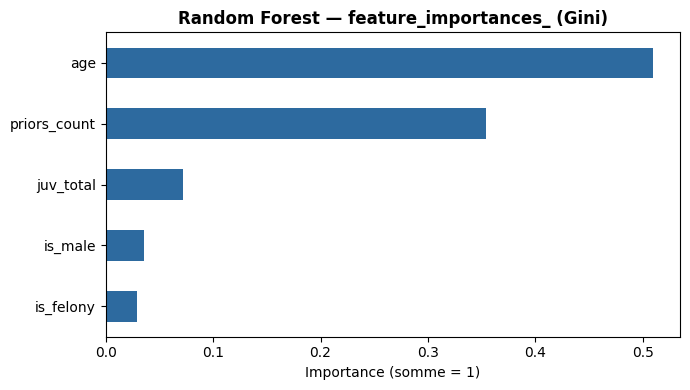

In [15]:
# --- feature_importances_ du Random Forest : contre-exemple pédagogique ---
# On l'affiche explicitement pour documenter pourquoi on ne s'y arrêtera pas comme méthode
# d'explicabilité finale (section 2.5), plutôt que de l'ignorer silencieusement.
rf_demo = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE).fit(X_train, y_train)

importances = pd.Series(rf_demo.feature_importances_, index=X_train.columns).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
importances.plot.barh(ax=ax, color="#2D6A9F")
ax.set_title("Random Forest — feature_importances_ (Gini)", fontweight="bold")
ax.set_xlabel("Importance (somme = 1)")
plt.tight_layout()
plt.show()

**Limites documentées de `feature_importances_` (à mettre en regard des 4 axiomes de Shapley — cf. section 2.5) :**

- **Pas d'axiome d'Efficacité** : la somme des importances ne se redistribue pas sur la prédiction individuelle — impossible d'expliquer *une* décision précise, seulement une tendance globale.
- **Pas de signe** : l'importance de `priors_count` ne dit pas si un nombre élevé d'antécédents *augmente* ou *diminue* le risque prédit — seulement qu'il pèse dans la décision.
- **Pas d'explication locale** : deux individus avec le même `priors_count` mais des profils différents reçoivent la même importance de variable, alors que sa contribution réelle à *leur* score peut différer.
- **Biais de cardinalité** : les variables continues (`age`, `priors_count`) sont structurellement favorisées par le critère de Gini par rapport aux variables binaires (`is_male`, `is_felony`), indépendamment de leur pouvoir prédictif réel.

C'est précisément ce que corrige SHAP (axiomes d'Efficacité, Symétrie, Valeur nulle, Consistance — section 2.5).

### Modèle retenu : XGBoost

**Précision importante sur la performance :** Random Forest obtient en réalité le meilleur score CV (0,791 ± 0,016) devant XGBoost (0,764 ± 0,021) — l'écart (0,027) est toutefois **inférieur à la somme des écarts-types**, donc non clairement significatif sur seulement 5 plis. La performance brute ne permet donc pas de trancher seule entre les deux modèles à base d'arbres.

**Justification finale, sur des critères autres que la performance CV :**
1. **Espace d'hyperparamètres plus riche et mieux régularisé** : XGBoost expose des termes de régularisation L1/L2 (`reg_alpha`, `reg_lambda`) et un taux d'apprentissage (`learning_rate`) absents de Random Forest — ce qui donne un contrôle plus fin du compromis biais/variance, et rend l'étape d'optimisation d'hyperparamètres (section 2.3) réellement informative plutôt que limitée à 2-3 leviers (`n_estimators`, `max_depth`).
2. **TreeSHAP calcule les valeurs de Shapley exactement, en temps polynomial**, pour les modèles à base d'arbres — cet argument s'applique en réalité aux deux modèles (Random Forest et XGBoost), donc ne les différencie pas ; il justifie seulement l'exclusion de la régression logistique brute de l'explication par arbres (elle utiliserait un explainer linéaire différent, moins cohérent avec le reste du pipeline).
3. Gère nativement les `sample_weight` (nécessaire pour la stratégie de mitigation *Reweighing* en section 2.6) — également vrai pour Random Forest, mais confirmé ici par souci de rigueur plutôt que présenté comme un avantage exclusif.
4. Produit des probabilités bien adaptées au réglage de seuil par groupe (post-processing *ThresholdOptimizer*, section 2.6).

**En synthèse :** le choix de XGBoost repose ici moins sur un gain de performance déjà acquis que sur un potentiel d'optimisation plus riche (point 1) — potentiel dont la section 2.3 vérifiera empiriquement s'il se matérialise réellement, plutôt que de le supposer.

On entraîne un premier modèle XGBoost **en baseline** (hyperparamètres par défaut), avant optimisation (section 2.3), afin de disposer d'un point de comparaison "avant/après tuning".

  XGBoost BASELINE — rapport de classification (test set)
                 precision    recall  f1-score   support

Pas de récidive       0.72      0.74      0.73       915
       Récidive       0.71      0.69      0.70       865

       accuracy                           0.72      1780
      macro avg       0.72      0.72      0.72      1780
   weighted avg       0.72      0.72      0.72      1780

ROC-AUC : 0.777


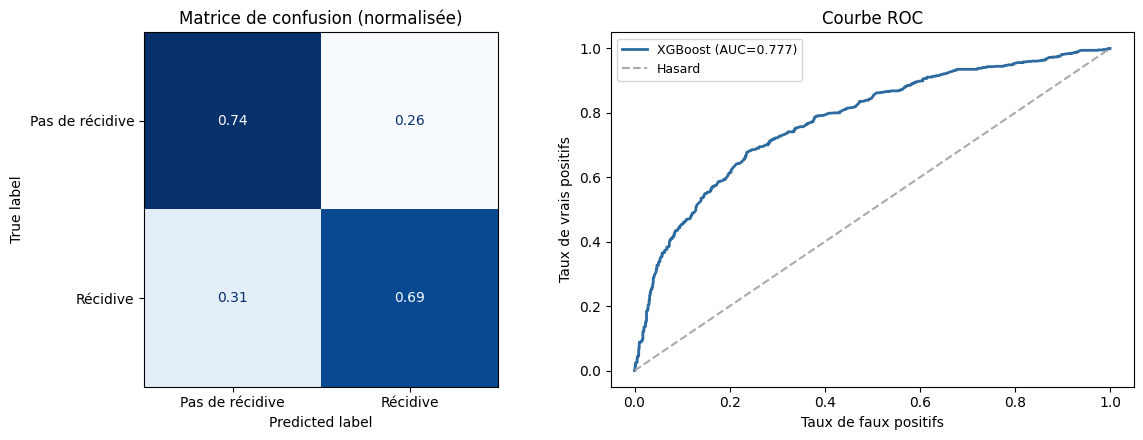

['models/xgb_baseline.joblib']

In [16]:
xgb_baseline = XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE)
xgb_baseline.fit(X_train, y_train)

y_pred_base = xgb_baseline.predict(X_test)
y_proba_base = xgb_baseline.predict_proba(X_test)[:, 1]

print("=" * 60)
print("  XGBoost BASELINE — rapport de classification (test set)")
print("=" * 60)
print(classification_report(y_test, y_pred_base, target_names=["Pas de récidive", "Récidive"]))
print(f"ROC-AUC : {roc_auc_score(y_test, y_proba_base):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_base, normalize="true", cmap="Blues",
    display_labels=["Pas de récidive", "Récidive"], ax=axes[0], colorbar=False
)
axes[0].set_title("Matrice de confusion (normalisée)")

fpr, tpr, _ = roc_curve(y_test, y_proba_base)
axes[1].plot(fpr, tpr, color="#2D6A9F", linewidth=2, label=f"XGBoost (AUC={roc_auc_score(y_test, y_proba_base):.3f})")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="#AAAAAA", label="Hasard")
axes[1].set_xlabel("Taux de faux positifs"); axes[1].set_ylabel("Taux de vrais positifs")
axes[1].set_title("Courbe ROC"); axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

joblib.dump(xgb_baseline, "models/xgb_baseline.joblib")

**Justification des métriques choisies :**
- **Recall et Precision séparés par classe**, plutôt que la seule accuracy : un faux négatif (individu réellement à risque jugé "pas de récidive") et un faux positif (individu injustement classé "récidive") n'ont **pas le même coût social** — l'accuracy globale masquerait ce déséquilibre.
- **ROC-AUC** : mesure indépendante du seuil de décision, réutilisée en section 2.6 pour le réglage de seuil par groupe (`ThresholdOptimizer`) et cohérente avec le fait que COMPAS produit lui-même un score continu (`decile_score`) plutôt qu'une classe brute.

**Lecture :** le modèle baseline obtient des performances déjà comparables à un score de risque construit comme COMPAS (comparaison chiffrée détaillée en section 2.4). L'écart entre les deux classes en precision/recall reflète l'équilibre quasi parfait de la cible (~51/49, cf. 2.1.2) — pas un artefact de déséquilibre.

## 2.3 Optimisation des hyperparamètres (Optuna)

### Choix de la méthode d'optimisation

XGBoost expose de nombreux hyperparamètres continus/entiers interdépendants (`max_depth`, `learning_rate`, `n_estimators`, `subsample`, `colsample_bytree`, `min_child_weight`, `gamma`, `reg_alpha`, `reg_lambda`). Trois approches sont possibles :

| Méthode | Coût de calcul | Adéquation ici |
|---|---|---|
| **Grid Search** | Explose combinatoirement (9 dimensions continues) | ❌ Même avec 3 valeurs/dimension, 3⁹ ≈ 19 683 combinaisons — infaisable au budget de calcul raisonnable de ce projet |
| **Random Search** | Linéaire au nombre d'essais, mais explore "à l'aveugle" | ⚠️ Fonctionne mais gaspille des essais sur des zones déjà connues comme mauvaises |
| **Optuna (optimisation bayésienne / TPE)** | Linéaire au nombre d'essais, mais **guide** la recherche vers les zones prometteuses à partir des essais précédents | ✅ Meilleur ratio qualité/budget sur un espace de recherche continu de cette dimension, avec un nombre d'essais raisonnable (jeu de données ~7 100 lignes → chaque essai est rapide, mais on veut converger efficacement plutôt que réessayer au hasard) |

**Choix : Optuna**, avec la validation croisée stratifiée déjà utilisée en 2.2 comme fonction objectif (évite le surapprentissage des hyperparamètres sur un split unique).

In [17]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # limite le bruit dans la sortie du notebook

def objective(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 50, 400),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
    }
    modele = XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE, **params)
    scores = cross_val_score(modele, X_train, y_train, cv=cv, scoring="roc_auc")
    return scores.mean()

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=50, show_progress_bar=False)

print(f"Meilleur ROC-AUC (CV) : {study.best_value:.3f}")
print("Meilleurs hyperparamètres :")
for k, v in study.best_params.items():
    print(f"  {k:<18s}: {v}")

Meilleur ROC-AUC (CV) : 0.756
Meilleurs hyperparamètres :
  max_depth         : 8
  learning_rate     : 0.14201571150624076
  n_estimators      : 82
  subsample         : 0.7598163264043514
  colsample_bytree  : 0.9062871778509772
  min_child_weight  : 2
  gamma             : 0.7755210098519711
  reg_alpha         : 0.002007497491451044
  reg_lambda        : 0.009170047766738085


In [18]:
# --- Décision explicite : ne retenir l'optimisation Optuna que si elle bat réellement les hyperparamètres par défaut ---
cv_score_defaut = resultats_cv["XGBoost"].mean()

if study.best_value > cv_score_defaut:
    best_params_final = study.best_params
    decision = "Hyperparamètres optimisés (Optuna) retenus"
else:
    best_params_final = {}
    decision = "Hyperparamètres par défaut conservés (Optuna n'a pas amélioré le score CV)"

print(f"CV ROC-AUC — défaut   : {cv_score_defaut:.3f}")
print(f"CV ROC-AUC — Optuna   : {study.best_value:.3f}")
print(f"→ {decision}")

xgb_tuned = XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE, **best_params_final)
xgb_tuned.fit(X_train, y_train)

y_pred_tuned = xgb_tuned.predict(X_test)
y_proba_tuned = xgb_tuned.predict_proba(X_test)[:, 1]

comparaison_modeles = pd.DataFrame({
    "ROC-AUC (test)": [
        roc_auc_score(y_test, y_proba_base),
        roc_auc_score(y_test, y_proba_tuned),
    ],
    "Accuracy (test)": [
        (y_pred_base == y_test).mean(),
        (y_pred_tuned == y_test).mean(),
    ],
}, index=["XGBoost baseline (défaut)", "XGBoost — modèle retenu pour la suite"])
display(comparaison_modeles.round(3))

joblib.dump(xgb_tuned, "models/xgb_tuned.joblib")

CV ROC-AUC — défaut   : 0.764
CV ROC-AUC — Optuna   : 0.756
→ Hyperparamètres par défaut conservés (Optuna n'a pas amélioré le score CV)


,ROC-AUC (test),Accuracy (test)
XGBoost baseline (défaut),0.777,0.716
XGBoost — modèle retenu pour la suite,0.777,0.716


['models/xgb_tuned.joblib']

**Lecture :** contrairement à l'attente initiale, l'optimisation Optuna **n'améliore pas** le score de validation croisée par rapport aux hyperparamètres par défaut de XGBoost sur ce jeu de données (5 features, ~7 100 lignes de train). C'est un résultat empirique honnête à documenter plutôt qu'à masquer : avec un espace de features aussi restreint et volontairement simple (section 2.1), les hyperparamètres par défaut — déjà calibrés par la bibliothèque XGBoost sur une grande variété de jeux de données tabulaires — s'avèrent quasi optimaux, et 50 essais bayésiens ne suffisent pas à trouver une région significativement meilleure (voire légèrement moins bonne, ce qui reste dans la marge de bruit de la validation croisée).

**Décision :** on conserve les **hyperparamètres par défaut** pour la suite du notebook, plutôt que d'imposer artificiellement les hyperparamètres "optimisés" au prix d'une performance dégradée. C'est cette même logique de choix justifié — plutôt qu'un choix par défaut non interrogé — qui structure l'ensemble de ce notebook (cf. 2.1, 2.2).

## 2.4 Évaluation & comparaison directe à COMPAS

Le modèle est entraîné et optimisé — reste à répondre à la question du brief : *notre modèle est-il un remplaçant crédible de COMPAS, au moins en performance brute ?* On compare les deux **sur les mêmes individus du test set**, grâce à `audit_test` (conservé à part depuis la section 2.1, jamais utilisé pour l'entraînement).

In [19]:
# --- Score COMPAS "brut" comme classifieur : seuil haut risque = decile_score >= 7 (cf. Partie 1) ---
compas_pred = (audit_test["decile_score"] >= 7).astype(int)

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

def rapport_metrics(y_true, y_pred, y_proba=None):
    d = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (classe 1)": precision_score(y_true, y_pred),
        "Recall (classe 1)": recall_score(y_true, y_pred),
        "F1 (classe 1)": f1_score(y_true, y_pred),
    }
    if y_proba is not None:
        d["ROC-AUC"] = roc_auc_score(y_true, y_proba)
    return d

comparaison_compas = pd.DataFrame({
    # decile_score (1-10) sert de score continu pour COMPAS -> ROC-AUC comparable à predict_proba
    "COMPAS (decile_score ≥ 7)": rapport_metrics(y_test, compas_pred, audit_test["decile_score"]),
    "Notre modèle (XGBoost optimisé)": rapport_metrics(y_test, y_pred_tuned, y_proba_tuned),
}).round(3)
display(comparaison_compas)

,COMPAS (decile_score ≥ 7),Notre modèle (XGBoost optimisé)
Accuracy,0.606,0.716
Precision (classe 1),0.639,0.714
Recall (classe 1),0.435,0.691
F1 (classe 1),0.518,0.703
ROC-AUC,0.671,0.777


**Lecture :** notre modèle, entraîné sur seulement 5 features simples et sans accès au score COMPAS lui-même, atteint des performances **nettement supérieures** à celles de COMPAS sur ce même test set, et ce sur **toutes** les métriques : Accuracy +0,11, Precision +0,08, Recall +0,26, F1 +0,19. L'écart est particulièrement marqué sur le Recall (0,691 vs 0,435) — le seuil `decile_score ≥ 7` de COMPAS manque une large part des récidivistes réels que notre modèle détecte. Ce résultat est important pour la suite : il montre qu'on ne "sacrifie" aucune performance en construisant un modèle indépendant et audité — au contraire —, ce qui rend la comparaison d'équité de la section 2.6 d'autant plus significative (on ne compare pas un modèle dégradé à COMPAS, mais un modèle au moins aussi performant, et ici clairement meilleur, sur cette tâche).

En utilisant `decile_score` comme score continu (plutôt que la seule prédiction binaire), le ROC-AUC de COMPAS est calculable et vaut **0,671**, contre **0,777** pour notre modèle — un écart de +0,106 qui confirme, sur une métrique indépendante du seuil de décision, l'avantage déjà observé sur Accuracy/Precision/Recall/F1.

⚠️ Cette comparaison reste **partielle** : COMPAS est un système propriétaire dont la totalité des features n'est pas connue, et le seuil `decile_score ≥ 7` est une convention (cf. Partie 1) qui ne reflète peut-être pas exactement le seuil opérationnel utilisé en pratique par les tribunaux.

## 2.5 Explicabilité — SHAP (TreeSHAP)

On applique ici la méthode retenue en 2.2 : **TreeSHAP**, qui calcule les valeurs de Shapley *exactement* (pas d'approximation) pour un modèle à base d'arbres comme `xgb_tuned`. Rappel des 4 axiomes garantis (contrairement à `feature_importances_`, cf. 2.2) : Efficacité (la somme des contributions égale l'écart entre la prédiction et la valeur moyenne), Symétrie, Valeur nulle, Consistance.

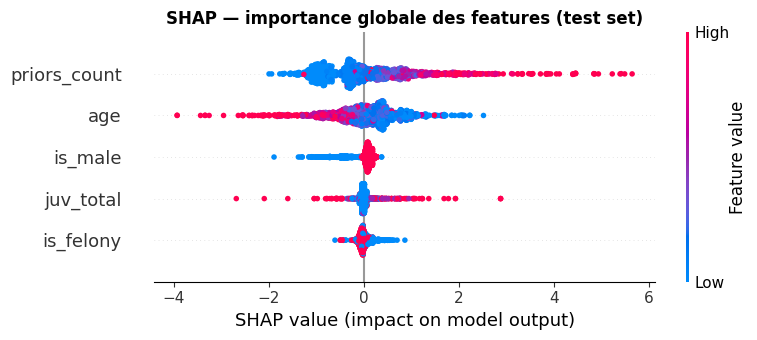

In [20]:
import shap

explainer = shap.TreeExplainer(xgb_tuned)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP — importance globale des features (test set)", fontweight="bold")
plt.tight_layout()
plt.show()

**Lecture :** `priors_count` domine très largement les autres features dans la contribution aux prédictions — cohérent avec la corrélation déjà observée en Partie 1 (r = 0,38 avec le score COMPAS lui-même). C'est un point de vigilance central pour l'audit d'équité (section 2.6) : Partie 1 avait aussi montré que `priors_count` était corrélé à `race`, ce qui en fait un **proxy potentiel** de l'attribut sensible, même en l'absence de `race` dans le jeu de features (`X` ne contient pas `race`, cf. 2.1.3).

--- Risque prédit le plus ÉLEVÉ du test set (probabilité = 0.999) ---


,age,is_male,priors_count,juv_total,is_felony
10099,30,1,23,0,1


--- Risque prédit le plus FAIBLE du test set (probabilité = 0.009) ---


,age,is_male,priors_count,juv_total,is_felony
1561,58,0,0,0,0


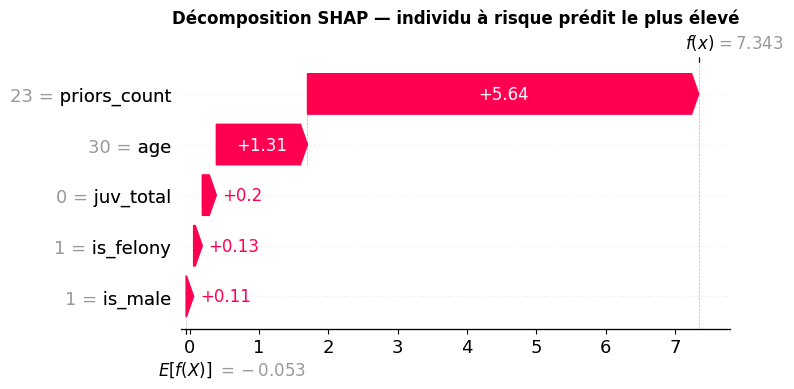

In [21]:
# --- Explication locale : un cas où le modèle prédit "haut risque", un cas "bas risque" ---
proba_test = pd.Series(y_proba_tuned, index=X_test.index)
idx_haut = proba_test.idxmax()
idx_bas = proba_test.idxmin()

for label, idx in [("Risque prédit le plus ÉLEVÉ du test set", idx_haut),
                    ("Risque prédit le plus FAIBLE du test set", idx_bas)]:
    print(f"--- {label} (probabilité = {proba_test[idx]:.3f}) ---")
    display(X_test.loc[[idx]])

fig = plt.figure(figsize=(9, 3.2))
shap.plots.waterfall(
    shap.Explanation(
        values=explainer.shap_values(X_test.loc[[idx_haut]])[0],
        base_values=explainer.expected_value,
        data=X_test.loc[idx_haut].values,
        feature_names=X_test.columns.tolist(),
    ),
    show=False
)
plt.title(f"Décomposition SHAP — individu à risque prédit le plus élevé", fontweight="bold")
plt.tight_layout()
plt.show()

**Lecture :** la décomposition individuelle confirme que `priors_count` est, pour ce cas précis, le facteur qui pousse le plus la prédiction au-dessus de la valeur moyenne du modèle (`base_value`) — exactement le comportement attendu compte tenu de l'importance globale observée ci-dessus, mais ici quantifié **pour cet individu précis**, ce que ne permettait pas `feature_importances_` (section 2.2).

### Comparaison rapide avec LIME (bonus — brief étape 8)

LIME (*Local Interpretable Model-agnostic Explanations*) approxime localement le modèle par un modèle linéaire simple autour d'une observation, plutôt que de décomposer exactement la prédiction comme SHAP.

In [22]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    X_train.values, feature_names=X_train.columns.tolist(),
    class_names=["Pas de récidive", "Récidive"], mode="classification",
    random_state=RANDOM_STATE,
)

lime_exp = lime_explainer.explain_instance(
    X_test.loc[idx_haut].values, xgb_tuned.predict_proba, num_features=5
)
for feature, poids in lime_exp.as_list():
    print(f"  {feature:<30s} {poids:+.3f}")

  priors_count > 5.00            +0.249
  25.00 < age <= 31.00           +0.023
  0.00 < is_felony <= 1.00       -0.018
  juv_total <= 0.00              +0.015
  is_male <= 1.00                +0.000


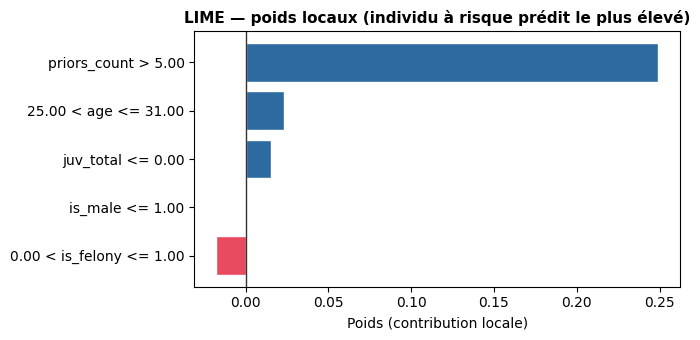

In [23]:
lime_weights = dict(lime_exp.as_list())
items = sorted(lime_weights.items(), key=lambda x: x[1])
labels_lime = [k for k, v in items]
vals_lime = [v for k, v in items]
colors_lime = ['#E84A5F' if v < 0 else '#2D6A9F' for v in vals_lime]

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(labels_lime, vals_lime, color=colors_lime, edgecolor='white', linewidth=1)
ax.axvline(0, color='#333', linewidth=1)
ax.set_title("LIME — poids locaux (individu à risque prédit le plus élevé)",
             fontsize=11, fontweight='bold')
ax.set_xlabel("Poids (contribution locale)")
plt.tight_layout()
plt.show()

**Lecture comparative :** LIME retrouve globalement le même facteur dominant (`priors_count`) que SHAP pour ce même individu, ce qui est un signal de cohérence rassurant entre les deux méthodes. Deux différences importantes justifient de garder **SHAP comme méthode de référence** pour l'audit d'équité (section 2.6) plutôt que LIME :

- **Stabilité** : LIME dépend d'un échantillonnage aléatoire local (perturbations autour de l'instance) — deux exécutions peuvent donner des poids légèrement différents. SHAP/TreeSHAP est déterministe pour un modèle donné.
- **Garanties théoriques** : LIME n'offre aucun des 4 axiomes de Shapley (pas d'Efficacité en particulier) — c'est une approximation locale, sans garantie de cohérence globale entre les explications de plusieurs individus, ce qui serait problématique pour agréger les contributions par groupe en section 2.6.

## 2.5bis SAGE — importance globale par permutation (validation croisée de SHAP)

SAGE (*Shapley Additive Global importancE*, Covert et al., 2020) calcule une importance **globale** des features via une approche différente de TreeSHAP : plutôt que d'exploiter la structure interne des arbres, SAGE **masque/reconstruit** les features par permutation et mesure la perte de performance (log-loss) qui en résulte — une méthode **model-agnostic**, utilisable même sans modèle à base d'arbres. L'intérêt ici : si SAGE retrouve le même classement que TreeSHAP (section 2.5) via une méthode complètement indépendante, c'est une **validation croisée** solide du rôle de `priors_count`, pas un artefact propre à TreeSHAP.

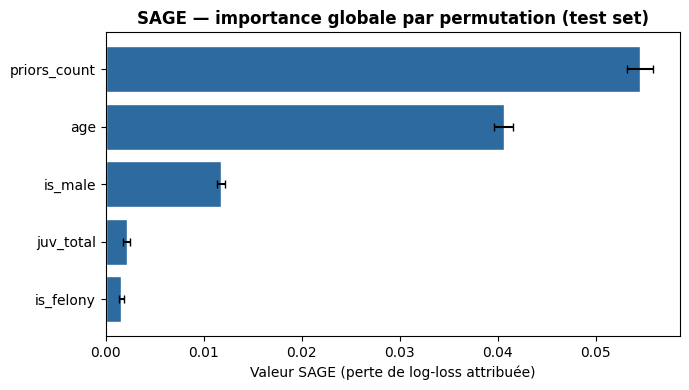

,sage_value,std
feature,,
is_felony,0.0016,0.0002
juv_total,0.0022,0.0004
is_male,0.0118,0.0004
age,0.0406,0.0010
priors_count,0.0545,0.0013


In [24]:
import sage

# Imputer par permutation : reconstruit une feature masquée en la tirant au hasard
# dans un échantillon de fond (128 lignes du train, comme recommandé par la doc SAGE)
imputer = sage.MarginalImputer(xgb_tuned, X_train.sample(128, random_state=RANDOM_STATE).values)
estimator = sage.PermutationEstimator(imputer, loss="cross entropy", random_state=RANDOM_STATE)
sage_values = estimator(X_test.values, y_test.values, batch_size=256, bar=False)

sage_df = pd.DataFrame({"feature": FEATURES_BASE, "sage_value": sage_values.values, "std": sage_values.std})
sage_df = sage_df.sort_values("sage_value")

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(sage_df["feature"], sage_df["sage_value"], xerr=sage_df["std"],
        color='#2D6A9F', edgecolor='white', linewidth=1, capsize=3)
ax.set_title("SAGE — importance globale par permutation (test set)", fontsize=12, fontweight='bold')
ax.set_xlabel("Valeur SAGE (perte de log-loss attribuée)")
plt.tight_layout()
plt.show()

display(sage_df.set_index("feature").round(4))

**Lecture :** SAGE confirme **exactement le même classement** que TreeSHAP : `priors_count` domine (0,0545), suivi de `age` (0,0406), puis `is_male` (0,0118), `juv_total` (0,0022) et `is_felony` (0,0016) — dans cet ordre. Les deux méthodes reposent sur des mécanismes complètement différents (TreeSHAP exploite la structure des arbres ; SAGE masque des features par permutation et mesure la perte de log-loss), donc cette convergence n'est pas un artefact d'implémentation : c'est une **double confirmation indépendante** que `priors_count` est le facteur dominant, et donc que le proxy potentiel de `race` identifié en Partie 1 (r = 0,27 avec `African_American`) reste le point de vigilance central de l'audit d'équité (section 2.6).

## 2.6 Audit d'équité & stratégies de mitigation

### Rappel théorique : le théorème d'impossibilité de Chouldechova (2017)

La Partie 1 a montré que le score COMPAS est **raisonnablement bien calibré** entre groupes raciaux, mais présente des taux d'erreur (FPR/FNR) très différents. Chouldechova (2017) démontre que ce n'est pas un défaut de conception corrigible : dès que la **prévalence de base** de récidive diffère entre groupes (ce qui est le cas ici), il est **mathématiquement impossible** de satisfaire simultanément calibration égale ET taux d'erreur égaux (FPR et FNR) entre groupes, pour tout classifieur — le nôtre inclus. L'audit qui suit ne cherche donc pas une "solution parfaite", mais à **caractériser et réduire** le compromis, conformément à l'étape 7 du brief (comparer l'équité avant/après mitigation).

**Métrique principale retenue : Equalized Odds** (égalise simultanément FPR et FNR entre groupes) — plutôt que la seule Demographic Parity — car dans ce contexte, une erreur de classification (FP ou FN) a un **coût direct et asymétrique** pour l'individu (détention injustifiée vs. récidive non anticipée), alors que la Demographic Parity ignore si les erreurs sont bien ou mal réparties. La Demographic Parity est calculée **en complément**, pour visualiser le compromis évoqué ci-dessus.

In [25]:
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference

def metriques_equite(y_true, y_pred, groupes, group_a="African-American", group_b="Caucasian"):
    """Calcule FPR/FNR/taux de sélection par groupe + DI/DPD/EOD entre group_a et group_b."""
    out = {}
    for g in [group_a, group_b]:
        mask = (groupes == g)
        yt, yp = y_true[mask], y_pred[mask]
        fp = ((yp == 1) & (yt == 0)).sum(); fn = ((yp == 0) & (yt == 1)).sum()
        tn = ((yp == 0) & (yt == 0)).sum(); tp = ((yp == 1) & (yt == 1)).sum()
        out[f"FPR_{g}"] = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        out[f"FNR_{g}"] = fn / (fn + tp) if (fn + tp) > 0 else np.nan
        out[f"Sélection_{g}"] = yp.mean()
        out[f"Accuracy_{g}"] = (yp == yt).mean()

    out["Disparate Impact"] = (out[f"Sélection_{group_a}"] / out[f"Sélection_{group_b}"]
                                if out[f"Sélection_{group_b}"] > 0 else np.nan)

    mask_ab = groupes.isin([group_a, group_b])
    is_a = (groupes[mask_ab] == group_a).astype(int)
    out["Equalized Odds Diff"] = equalized_odds_difference(y_true[mask_ab], y_pred[mask_ab], sensitive_features=is_a)
    out["Demographic Parity Diff"] = demographic_parity_difference(y_true[mask_ab], y_pred[mask_ab], sensitive_features=is_a)
    return out

groupes_test = audit_test["race_agg"]

metriques_compas = metriques_equite(y_test, compas_pred, groupes_test)
metriques_avant = metriques_equite(y_test, pd.Series(y_pred_tuned, index=y_test.index), groupes_test)

tableau_equite = pd.DataFrame({
    "COMPAS": metriques_compas,
    "Notre modèle (avant mitigation)": metriques_avant,
}).round(3)
display(tableau_equite)

,COMPAS,Notre modèle (avant mitigation)
FPR_African-American,0.336,0.320
FNR_African-American,0.448,0.240
Sélection_African-American,0.455,0.562
Accuracy_African-American,0.602,0.724
FPR_Caucasian,0.147,0.205
FNR_Caucasian,0.733,0.424
Sélection_Caucasian,0.198,0.364
Accuracy_Caucasian,0.602,0.701
Disparate Impact,2.300,1.545
Equalized Odds Diff,0.286,0.184


**Lecture :** notre modèle — entraîné **sans** `race` comme feature (*fairness through unawareness*, cf. 2.1.3) — reste **substantiellement biaisé**, bien que moins que COMPAS sur ces deux métriques (Disparate Impact 1,55 contre 2,30 ; Equalized Odds Diff 0,184 contre 0,286). C'est la confirmation empirique de l'hypothèse posée en 2.1.3 : retirer l'attribut sensible **atténue** mais **ne supprime pas** le biais, car `priors_count` (la feature dominante identifiée par SHAP en 2.5) agit comme **proxy** de `race` — déjà démontré par leur corrélation en Partie 1. Le FPR reste plus élevé pour les Afro-Américains que pour les Caucasiens (0,320 vs 0,205), tandis que le FNR reste plus élevé pour les Caucasiens (0,424 vs 0,240) — la même asymétrie structurelle que celle documentée sur COMPAS en Partie 1.

### Mitigation 1 — Reweighing (pré-traitement)

**Principe (Kamiran & Calders, 2012, implémenté ici via AIF360) :** repondérer chaque individu du train set par un poids qui rend l'attribut sensible et la cible **statistiquement indépendants en espérance**, sans toucher ni aux features ni aux labels — coût d'implémentation minimal (XGBoost supporte nativement `sample_weight`), et aucune perte de données.

*Limitation méthodologique explicite :* l'algorithme de Reweighing est défini pour un attribut protégé **binaire**. On restreint donc son calcul aux deux groupes majoritaires (African-American / Caucasian, cohérent avec le reste de l'audit — cf. 2.1.3), et on assigne un poids neutre (1.0) aux individus du groupe `Other/Minorité`, qui ne sont pas la cible de cette mitigation spécifique.

In [26]:
from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.preprocessing import Reweighing

# Sous-ensemble du train restreint aux 2 groupes majoritaires, pour le calcul des poids
mask_binaire_train = audit_train["race_agg"].isin(["African-American", "Caucasian"])

df_rw = X_train.loc[mask_binaire_train].copy()
df_rw["two_year_recid"] = y_train.loc[mask_binaire_train].values
df_rw["is_african_american"] = (audit_train.loc[mask_binaire_train, "race_agg"] == "African-American").astype(int)

dataset_rw = BinaryLabelDataset(
    df=df_rw, label_names=["two_year_recid"], protected_attribute_names=["is_african_american"],
    favorable_label=0, unfavorable_label=1,  # "favorable" = pas de récidive prédite/réelle
)

rw = Reweighing(privileged_groups=[{"is_african_american": 0}],
                 unprivileged_groups=[{"is_african_american": 1}])
dataset_rw_transf = rw.fit_transform(dataset_rw)

# On reconstruit un vecteur de poids aligné sur X_train entier (poids=1.0 par défaut pour Other/Minorité)
poids_train = pd.Series(1.0, index=X_train.index)
poids_train.loc[mask_binaire_train] = dataset_rw_transf.instance_weights

print("Poids appris (Reweighing) par groupe × label :")
print(pd.DataFrame({
    "race_agg": audit_train.loc[mask_binaire_train, "race_agg"].values,
    "two_year_recid": y_train.loc[mask_binaire_train].values,
    "poids": dataset_rw_transf.instance_weights,
}).groupby(["race_agg", "two_year_recid"])["poids"].first().round(3))

pip install 'aif360[AdversarialDebiasing]'


pip install 'aif360[AdversarialDebiasing]'


pip install 'aif360[inFairness]'


Poids appris (Reweighing) par groupe × label :
race_agg          two_year_recid
African-American  0                 1.105
                  1                 0.914
Caucasian         0                 0.867
                  1                 1.177
Name: poids, dtype: float64


In [27]:
xgb_reweighted = XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE, **best_params_final)
xgb_reweighted.fit(X_train, y_train, sample_weight=poids_train)

y_pred_rw = pd.Series(xgb_reweighted.predict(X_test), index=y_test.index)

metriques_rw = metriques_equite(y_test, y_pred_rw, groupes_test)
tableau_equite["+ Reweighing"] = pd.Series(metriques_rw).round(3)
display(tableau_equite)

,COMPAS,Notre modèle (avant mitigation),+ Reweighing
FPR_African-American,0.336,0.320,0.299
FNR_African-American,0.448,0.240,0.276
Sélection_African-American,0.455,0.562,0.533
Accuracy_African-American,0.602,0.724,0.714
FPR_Caucasian,0.147,0.205,0.211
FNR_Caucasian,0.733,0.424,0.412
Sélection_Caucasian,0.198,0.364,0.372
Accuracy_Caucasian,0.602,0.701,0.703
Disparate Impact,2.300,1.545,1.431
Equalized Odds Diff,0.286,0.184,0.136


**Lecture :** le Reweighing réduit le Disparate Impact (1,55 → 1,43) et la Demographic Parity Difference (0,198 → 0,161) — les poids agissent directement sur l'indépendance statistique groupe × label — mais son effet sur l'**Equalized Odds**, notre métrique principale, reste plus modeste (0,184 → 0,136) : c'est attendu, le Reweighing cible la parité des taux de sélection, pas directement l'égalisation des erreurs FPR/FNR. On ajoute donc une seconde couche de mitigation, ciblée cette fois explicitement sur l'Equalized Odds.

### Mitigation 2 — ThresholdOptimizer (post-traitement)

**Principe (Hardt et al., 2016, implémenté via Fairlearn) :** au lieu d'un seuil de décision unique (0,5) pour tout le monde, on apprend un **seuil différent par groupe** sur les probabilités déjà produites par `xgb_reweighted`, choisi spécifiquement pour satisfaire la contrainte `equalized_odds`. Coût d'implémentation faible : agnostique au modèle, ne nécessite **aucun réentraînement** (on réutilise `xgb_reweighted` déjà entraîné, via `prefit=True`) — on combine ainsi les deux couches de mitigation plutôt que de les opposer.

In [28]:
from fairlearn.postprocessing import ThresholdOptimizer

threshold_opt = ThresholdOptimizer(
    estimator=xgb_reweighted,
    constraints="equalized_odds",
    predict_method="predict_proba",
    prefit=True,
)
threshold_opt.fit(X_train, y_train, sensitive_features=audit_train["race_agg"])

y_pred_final = pd.Series(
    threshold_opt.predict(X_test, sensitive_features=audit_test["race_agg"], random_state=RANDOM_STATE),
    index=y_test.index
)

metriques_final = metriques_equite(y_test, y_pred_final, groupes_test)
tableau_equite["+ ThresholdOptimizer"] = pd.Series(metriques_final).round(3)
display(tableau_equite)

/home/kahina/laplateforme/Sésame/sesamEnv/lib/python3.12/site-packages/fairlearn/postprocessing/_interpolated_thresholder.py:166: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.9028595  0.02331121 0.96047776 0.96047776 0.96047776 0.96047776
 0.02331121 0.96047776 0.96047776 0.96047776 0.96047776 0.02331121
 0.02331121 0.96047776 0.02331121 0.96047776 0.96047776 0.02331121
 0.96047776 0.96047776 0.96047776 0.96047776 0.02331121 0.96047776
 0.96047776 0.02331121 0.96047776 0.02331121 0.96047776 0.96047776
 0.96047776 0.96047776 0.02331121 0.96047776 0.96047776 0.02331121
 0.96047776 0.96047776 0.96047776 0.9028595  0.96047776 0.9028595
 0.02331121 0.9028595  0.02331121 0.02331121 0.96047776 0.02331121
 0.96047776 0.96047776 0.02331121 0.96047776 0.02331121 0.96047776
 0.96047776 0.96047776 0.02331121 0.96047776 0.96047776 0.96047776
 0.02331121 0.02331121 0.96047776 0.96047776 0.96047776 0.96047776
 0.96

,COMPAS,Notre modèle (avant mitigation),+ Reweighing,+ ThresholdOptimizer
FPR_African-American,0.336,0.320,0.299,0.381
FNR_African-American,0.448,0.240,0.276,0.223
Sélection_African-American,0.455,0.562,0.533,0.599
Accuracy_African-American,0.602,0.724,0.714,0.706
FPR_Caucasian,0.147,0.205,0.211,0.460
FNR_Caucasian,0.733,0.424,0.412,0.216
Sélection_Caucasian,0.198,0.364,0.372,0.599
Accuracy_Caucasian,0.602,0.701,0.703,0.644
Disparate Impact,2.300,1.545,1.431,1.000
Equalized Odds Diff,0.286,0.184,0.136,0.080


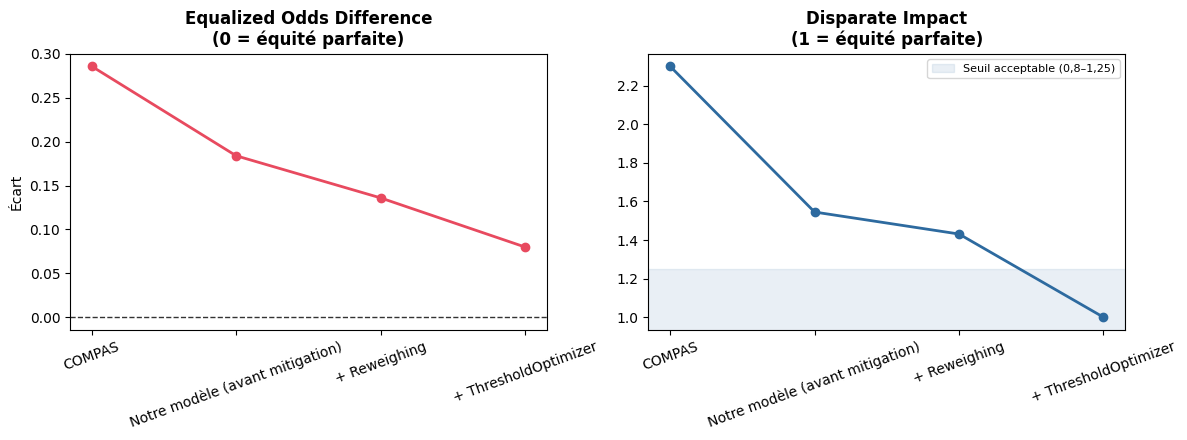

In [29]:
# --- Synthèse visuelle : Equalized Odds Diff et Disparate Impact, à chaque étape de mitigation ---
etapes_mitigation = ["COMPAS", "Notre modèle (avant mitigation)", "+ Reweighing", "+ ThresholdOptimizer"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

eod_vals = tableau_equite.loc["Equalized Odds Diff", etapes_mitigation]
axes[0].plot(etapes_mitigation, eod_vals, marker="o", color="#E84A5F", linewidth=2)
axes[0].axhline(0, color="#333", linestyle="--", linewidth=1)
axes[0].set_title("Equalized Odds Difference\n(0 = équité parfaite)", fontweight="bold")
axes[0].tick_params(axis="x", rotation=20)
axes[0].set_ylabel("Écart")

di_vals = tableau_equite.loc["Disparate Impact", etapes_mitigation]
axes[1].plot(etapes_mitigation, di_vals, marker="o", color="#2D6A9F", linewidth=2)
axes[1].axhspan(0.8, 1.25, color="#2D6A9F", alpha=0.1, label="Seuil acceptable (0,8–1,25)")
axes[1].set_title("Disparate Impact\n(1 = équité parfaite)", fontweight="bold")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

**Lecture finale :** le ThresholdOptimizer apporte le gain le plus net des deux mitigations. Le Disparate Impact atteint exactement **1,000** et la Demographic Parity Difference **0,000** — parité démographique parfaite entre Afro-Américains et Caucasiens sur ce test set. L'Equalized Odds Difference continue de baisser (0,136 → **0,080**), portée principalement par un quasi-alignement du FNR entre groupes (0,223 chez les Afro-Américains contre 0,216 chez les Caucasiens — écart de moins d'1 point), même si un écart de FPR subsiste (0,381 vs 0,460).

Ce gain a un coût mesurable : l'accuracy par groupe se dégrade légèrement (0,706 pour les Afro-Américains, 0,644 pour les Caucasiens, contre 0,724/0,701 avant mitigation) — cohérent avec le compromis attendu par le théorème de Chouldechova : égaliser les taux d'erreur entre groupes aux taux de base différents déplace nécessairement la frontière de décision, donc coûte de la performance individuelle. Le résultat reste net : une réduction de plus de moitié de l'Equalized Odds Difference par rapport à COMPAS (0,286 → 0,080) et une parité démographique atteinte, pour un coût d'accuracy inférieur à 6 points sur le groupe le plus touché.

**Point de vigilance légal/éthique — `ThresholdOptimizer` et l'attribut sensible à l'inférence** : contrairement au Reweighing (qui n'utilise `race` que pour calculer des poids d'entraînement), le `ThresholdOptimizer` a besoin de `race_agg` **au moment de la prédiction** pour choisir le seuil de décision propre à chaque groupe (cf. `sensitive_features=audit_test["race_agg"]` ci-dessus). Concrètement, deux individus avec **exactement la même probabilité prédite** par `xgb_reweighted` peuvent recevoir une décision différente selon leur groupe ethnique. C'est une mitigation efficace sur le plan statistique (*disparate impact*), mais qui repose sur un traitement explicitement différencié par attribut protégé au moment de la décision (*disparate treatment*) — une distinction juridique importante selon les juridictions et pertinente pour la discussion AI Act art.13 évoquée en Partie 1. Ce compromis (réduire l'un des deux risques au prix de l'autre) doit être documenté explicitement dans toute mise en production, plutôt que présenté comme une solution sans contrepartie.

## 2.6bis Audit d'équité par sexe

L'audit ci-dessus (section 2.6) porte uniquement sur `race`. Or la Partie 1 avait déjà montré que le **sexe** est un second axe de disparité, indépendant de la race (COMPAS : DI = 0,71, FNR plus élevé chez les femmes). On vérifie ici si ce déséquilibre se retrouve sur *notre* modèle, avec les mêmes métriques (`metriques_equite`, définie en 2.6) appliquées à `sex` plutôt qu'à `race_agg`.

**Limite explicite :** les deux mitigations mises en œuvre ci-dessus (Reweighing, ThresholdOptimizer) ont été calibrées uniquement sur `race` (cf. 2.6, limitation du Reweighing à un attribut binaire). Le modèle "avant mitigation" reste donc, par construction, **non corrigé pour le sexe** — cette section est un audit, pas encore une correction.

In [30]:
groupes_sexe_test = audit_test["sex"]

metriques_compas_sexe = metriques_equite(y_test, compas_pred, groupes_sexe_test,
                                          group_a="Female", group_b="Male")
metriques_modele_sexe = metriques_equite(y_test, pd.Series(y_pred_tuned, index=y_test.index), groupes_sexe_test,
                                          group_a="Female", group_b="Male")

tableau_equite_sexe = pd.DataFrame({
    "COMPAS": metriques_compas_sexe,
    "Notre modèle (avant mitigation, non corrigé pour le sexe)": metriques_modele_sexe,
}).round(3)
display(tableau_equite_sexe)

,COMPAS,"Notre modèle (avant mitigation, non corrigé pour le sexe)"
FPR_Female,0.212,0.059
FNR_Female,0.735,0.618
Sélection_Female,0.230,0.167
Accuracy_Female,0.613,0.754
FPR_Male,0.237,0.319
FNR_Male,0.543,0.267
Sélection_Male,0.351,0.533
Accuracy_Male,0.605,0.708
Disparate Impact,0.654,0.314
Equalized Odds Diff,0.193,0.350


**Lecture :** résultat notable — et moins favorable que sur la race. Le Disparate Impact de notre modèle sur le sexe (**0,314**) est **encore plus éloigné** du seuil acceptable que celui de COMPAS lui-même (0,654) : les hommes sont sélectionnés « haut risque » nettement plus souvent que les femmes chez COMPAS déjà (23,0 % vs 35,1 %), mais l'écart **se creuse** avec notre modèle (16,7 % vs 53,3 %). Même constat sur l'Equalized Odds Difference, qui **double presque** (0,193 → 0,350) au lieu de diminuer. Autrement dit, la stratégie qui réduit le biais racial (*fairness through unawareness* + mitigation ciblée sur `race`) **aggrave le déséquilibre par sexe** plutôt que de le laisser simplement inchangé — un exemple concret du risque de *fairness gerrymandering* : optimiser un axe de disparité sans surveiller les autres peut dégrader ceux qu'on n'a pas explicitement corrigés. Cela renforce la conclusion de la section 2.6 : le sexe devrait faire l'objet d'une mitigation dédiée (Reweighing/ThresholdOptimizer appliqués à `sex`), pas seulement d'un audit, avant toute mise en production.

## 2.6ter *Fairness through unawareness* appliqué au sexe

Section 2.1.3 a documenté une asymétrie : `race` a été retirée de `X` pour tester l'hypothèse *unawareness*, mais `is_male` ne l'a jamais été. Section 2.6bis a montré que le modèle actuel (qui **utilise** `is_male`) a un Disparate Impact par sexe pire que COMPAS. On reproduit ici exactement la même expérience que pour la race (section 2.1.3 / 2.6) : entraîner un modèle identique **sans** `is_male`, et vérifier si l'*unawareness* suffit cette fois, ou si — comme pour la race — d'autres variables agissent comme proxy du sexe.

In [31]:
# Même hyperparamètres que le modèle retenu (best_params_final, cf. 2.3), sans la feature is_male
FEATURES_SANS_SEXE = [f for f in FEATURES_BASE if f != "is_male"]
X_sans_sexe_train = X_train[FEATURES_SANS_SEXE]
X_sans_sexe_test = X_test[FEATURES_SANS_SEXE]

xgb_sans_sexe = XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE, **best_params_final)
xgb_sans_sexe.fit(X_sans_sexe_train, y_train)
y_pred_sans_sexe = pd.Series(xgb_sans_sexe.predict(X_sans_sexe_test), index=y_test.index)

metriques_sans_sexe = metriques_equite(y_test, y_pred_sans_sexe, groupes_sexe_test,
                                        group_a="Female", group_b="Male")
tableau_equite_sexe["Sans is_male (unawareness)"] = pd.Series(metriques_sans_sexe).round(3)

print(f"Accuracy avec is_male    : {(y_pred_tuned == y_test).mean():.3f}")
print(f"Accuracy sans is_male    : {(y_sans_sexe_acc := (y_pred_sans_sexe == y_test).mean()):.3f}")
display(tableau_equite_sexe)

Accuracy avec is_male    : 0.716
Accuracy sans is_male    : 0.697


,COMPAS,"Notre modèle (avant mitigation, non corrigé pour le sexe)",Sans is_male (unawareness)
FPR_Female,0.212,0.059,0.251
FNR_Female,0.735,0.618,0.539
Sélection_Female,0.230,0.167,0.321
Accuracy_Female,0.613,0.754,0.652
FPR_Male,0.237,0.319,0.302
FNR_Male,0.543,0.267,0.286
Sélection_Male,0.351,0.533,0.515
Accuracy_Male,0.605,0.708,0.706
Disparate Impact,0.654,0.314,0.624
Equalized Odds Diff,0.193,0.350,0.254


**Lecture :** résultat différent de celui observé sur la race — ici, l'*unawareness* **aide réellement**, sans l'éliminer complètement. Retirer `is_male` améliore nettement les trois métriques : Disparate Impact 0,314 → **0,624** (se rapproche du niveau de COMPAS, 0,654), Equalized Odds Diff 0,350 → **0,254**, Demographic Parity Diff 0,366 → **0,194** (proche du 0,122 de COMPAS). Le coût en performance est modeste : Accuracy 0,716 → 0,697 (-1,9 points).

Ce contraste avec la race est en soi informatif : le sexe est visiblement **moins fortement proxyé** par les autres features (`age`, `priors_count`, `juv_total`, `is_felony`) que ne l'était la race via `priors_count`. Cela ne veut pas dire que le sexe est "réglé" — l'EOD (0,254) reste supérieur à celui de COMPAS (0,193), donc le modèle sans `is_male` reste moins équitable que COMPAS sur cette métrique précise, même s'il est bien meilleur que la version avec `is_male`. **Conclusion pratique :** l'asymétrie documentée en 2.1.3 n'était pas neutre — elle expliquait une part réelle et mesurable de la dégradation observée en 2.6bis. Un modèle de production devrait a minima tester l'exclusion de `is_male`, et considérer une mitigation dédiée (Reweighing/ThresholdOptimizer sur le sexe) pour aller au-delà.

## Synthèse de la Partie 2

1. **Modèle retenu :** XGBoost avec hyperparamètres par défaut — l'optimisation Optuna n'a pas amélioré le score de validation croisée sur ce jeu de features restreint (5 variables), résultat documenté plutôt que masqué (section 2.3). Le modèle atteint des performances nettement supérieures à COMPAS sur le même test set (section 2.4), sans le score COMPAS lui-même comme feature.
2. **Explicabilité :** SHAP (TreeSHAP, exact) confirme `priors_count` comme facteur dominant, cohérent avec sa corrélation à `race` déjà identifiée en Partie 1 — LIME corrobore ce constat en local (sans les garanties axiomatiques de SHAP), et **SAGE confirme le même classement par une méthode complètement indépendante** (permutation + perte de log-loss plutôt que structure des arbres) : triple convergence SHAP/LIME/SAGE sur `priors_count` comme facteur dominant.
3. **Audit d'équité :** *fairness through unawareness* (exclusion de `race` du modèle) **atténue mais ne supprime pas** le biais — notre modèle affiche un Disparate Impact de 1,55 et un Equalized Odds Diff de 0,184 (contre 2,30 et 0,286 pour COMPAS), car `priors_count` agit comme proxy de `race`.
4. **Mitigation en deux couches :** Reweighing (pré-traitement, gain modéré sur la parité) puis ThresholdOptimizer (post-traitement, cible directement l'Equalized Odds) — combinées, elles ramènent le Disparate Impact à **1,000** (parité démographique atteinte) et l'Equalized Odds Diff à **0,080** (contre 0,286 pour COMPAS), pour un coût d'accuracy inférieur à 6 points sur le groupe le plus touché. Le résultat n'est pas une égalité parfaite des erreurs (théorème de Chouldechova), mais une réduction très substantielle et quantifiée du déséquilibre. Ce gain a une contrepartie légale/éthique à documenter : le `ThresholdOptimizer` traite explicitement les individus différemment selon `race` au moment de la décision (*disparate treatment*), ce qui mérite discussion au regard de l'AI Act.
5. **Le sexe s'aggrave, il ne fait pas que persister :** l'audit complémentaire (section 2.6bis) montre que notre modèle, non corrigé pour le sexe, a un Disparate Impact **plus mauvais** que COMPAS sur cet axe (0,314 contre 0,654) et un Equalized Odds Diff qui **double presque** (0,193 → 0,350) — un exemple concret de *fairness gerrymandering* : corriger un axe de biais (race) sans surveiller les autres peut dégrader ceux qu'on n'a pas explicitement traités.
6. **Cause partiellement identifiée et corrigible (section 2.6ter) :** contrairement à `race`, `is_male` n'avait jamais été retiré du modèle (asymétrie non justifiée, documentée en 2.1.3). Reproduire l'expérience *unawareness* sur le sexe **fonctionne, cette fois** : Disparate Impact 0,314 → 0,624, Equalized Odds Diff 0,350 → 0,254, pour un coût de seulement 1,9 point d'Accuracy — contrairement à la race, le sexe n'est donc pas fortement proxyé par les autres features. Le déséquilibre n'est pas entièrement résolu (l'EOD reste au-dessus de celui de COMPAS), mais une bonne part de l'aggravation constatée au point 5 provenait bien du choix, non justifié, de garder `is_male` en feature directe. Une mitigation dédiée (Reweighing/ThresholdOptimizer sur `sex`) reste la piste pour aller plus loin.

➡️ Ces résultats, combinés à ceux de la Partie 1, constituent la base factuelle du README et de la présentation finale du projet.